# Modeling Ideal Prototypes and Imperfect Instances:
## A Mathematical Interpretation of Plato’s Theory of Forms

Author: Ivan Goranov  
Course: Math for Developers  
Date: March 2026

### Introduction
Plato’s Theory of Forms proposes that the physical world is not the ultimate reality, but rather a representation of ideal and abstract entities called Forms. Physical objects are imperfect imitations of these ideal Forms. The Forms themselves are eternal, perfect, and independent of human perception.

This project does not attempt to prove the metaphysical existence of Forms. Instead, it models the concept mathematically by representing a Form as an ideal prototype in a vector space. Imperfect instances are generated as variations of this prototype by adding noise to it, and their deviation from the ideal is quantified using Euclidean distance. The project further explores whether the original prototype can be estimated from many imperfect instances using their mean.

### Hypothesis

If imperfect instances are generated as noisy variations around an ideal prototype (Platonic Form), then:

1. The Euclidean distance can quantify the degree of imperfection of each instance.
2. The mean of multiple imperfect instances will approximate the ideal prototype.

This models Plato's idea that physical instances are imperfect copies of ideal Forms.

### Mathematical Model

In this project, we represent the Platonic Form as an ideal prototype vector in a 2-dimensional space:

$$
\vec{v}^* = \begin{bmatrix} v_1^* \\ v_2^* \end{bmatrix}
$$

Here, $\vec{v}^*$ represents the perfect Form, modeled as a fixed point in $\mathbb{R}^2$.

Each imperfect instance is generated from the prototype with added noise:

$$
\vec{v}_i = \vec{v}^* + \vec{\varepsilon}_i
$$

where $\vec{\varepsilon}_i$ is a random noise vector representing deviation from the ideal Form.

The degree of imperfection of an instance is measured by the Euclidean distance between the instance and the prototype:

$$
d_i = \sqrt{(v_{i1} - v_1^*)^2 + (v_{i2} - v_2^*)^2}
$$

This distance quantifies how far an imperfect instance lies from the ideal Form.

Finally, we estimate the ideal prototype from multiple imperfect instances using the mean:

$$
\hat{\vec{v}}^* = \frac{1}{n} \sum_{i=1}^{n} \vec{v}_i
$$

We then compare $\hat{\vec{v}}^*$ to the original $\vec{v}^*$ to evaluate how well the mean of imperfect instances approximates the ideal Form.

### Implementation
A two-dimensional space is used so that imperfect instances can deviate from the prototype in multiple directions. This allows clearer visualization and more meaningful measurement of Euclidean distance between the ideal Form and its imperfect copies.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

##### Ideal Prototype
The ideal Form is represented as a fixed vector in two-dimensional space. In this model we choose the prototype vector v_form = [2,2], which acts as the reference point from which imperfect instances are generated.

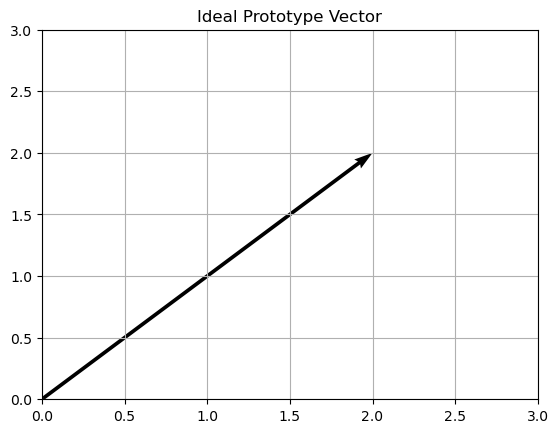

In [2]:
v_form = np.array([2, 2])

plt.quiver(0, 0, v_form[0], v_form[1], angles='xy', scale_units='xy', scale=1)
plt.title("Ideal Prototype Vector")
plt.xlim(0, 3)
plt.ylim(0, 3)
plt.grid()
plt.show()

##### Imperfect Instances: 
The noise is generated using Gaussian noise with mean 0 so that imperfections do not systematically shift the instances away from the ideal Form. This ensures that, on average, imperfect copies still reflect the underlying prototype.

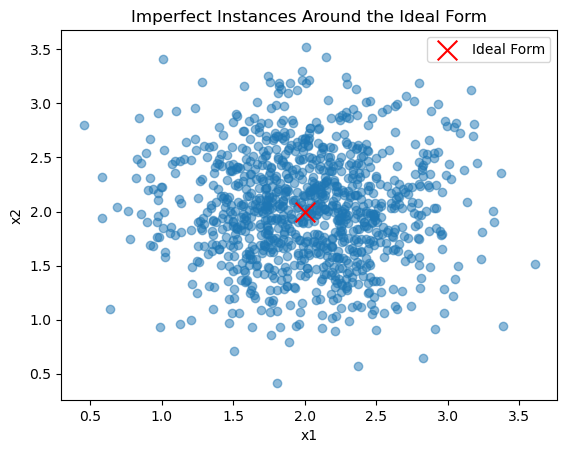

In [3]:
n_samples = 1000

noise = np.random.normal(0, 0.5, (n_samples, 2))
instances = v_form + noise

plt.scatter(instances[:,0], instances[:,1], alpha=0.5)
plt.scatter(v_form[0], v_form[1], color='red', marker='x', s=200, label='Ideal Form')

plt.title("Imperfect Instances Around the Ideal Form")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

The scatter plot shows that the imperfect instances are distributed around the ideal Form. Points closer to the Form represent smaller deviations, while points further away represent greater deviations.

##### Measuring Imperfection: Euclidean Distance
The degree of imperfection of an instance can be measured as the Euclidean distance between the instance and the ideal prototype using numpy.linalg.norm.

Average imperfection: 0.6266463433285842
Maximum imperfection: 1.7424722799876342
Minimum imperfection: 0.023679710614711167


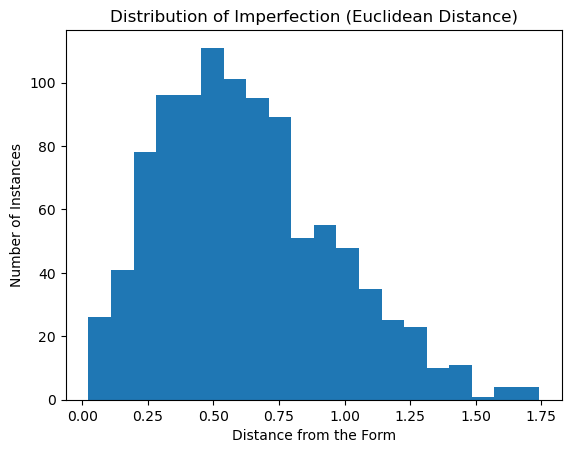

In [4]:
distances = np.linalg.norm(instances - v_form, axis=1)

print("Average imperfection:", np.mean(distances))
print("Maximum imperfection:", np.max(distances))
print("Minimum imperfection:", np.min(distances))

plt.hist(distances, bins=20)
plt.title("Distribution of Imperfection (Euclidean Distance)")
plt.xlabel("Distance from the Form")
plt.ylabel("Number of Instances")
plt.show()

The histogram clearly shows how imperfections are spread around the Form - most instances are located relatively close to the Form, while large deviations occur less frequently. This is the property of Gaussian noise which was used to create the instances. 

We can also test whether the average imperfection remains relatively stable when increasing the number of samples. 

In [5]:
for n in [100, 1000, 10000, 100000]:
    noise = np.random.normal(0, 0.5, (n, 2))
    temp_instances = v_form + noise
    distances = np.linalg.norm(temp_instances - v_form, axis=1)

    print(f"Samples: {n}, Average imperfection: {np.mean(distances):.4f}")

Samples: 100, Average imperfection: 0.5752
Samples: 1000, Average imperfection: 0.6325
Samples: 10000, Average imperfection: 0.6255
Samples: 100000, Average imperfection: 0.6261


The imperfection does remain relatively stable. The result is expected because the average distance from the Form depends mainly on the variance of the noise distribution rather than the number of instances.

##### Estimating the Ideal Form Using the Mean
The ideal Form can be estimated by averaging all generated instances.

In [6]:
estimated_form = np.mean(instances, axis=0)
error = np.linalg.norm(estimated_form - v_form)

print(f"Estimated Form: {estimated_form}")
print(f"True Form: {v_form}")
print(f"Estimation Error: {error}")

Estimated Form: [2.00648711 2.0224633 ]
True Form: [2 2]
Estimation Error: 0.02338124552415973


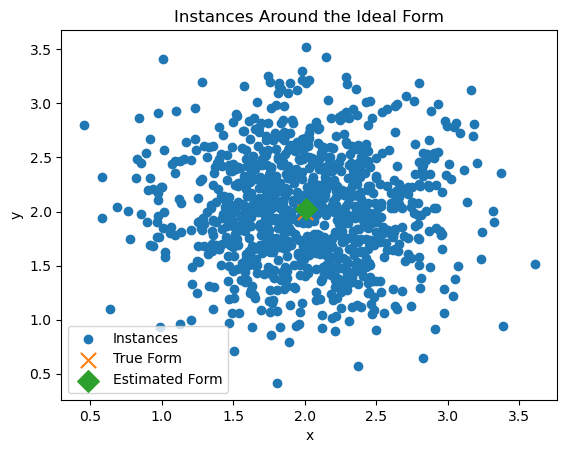

In [7]:
plt.scatter(instances[:,0], instances[:,1], label="Instances")
plt.scatter(v_form[0], v_form[1], marker='x', s=120, label="True Form")
plt.scatter(estimated_form[0], estimated_form[1], marker='D', s=120, label="Estimated Form")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Instances Around the Ideal Form")
plt.legend()
plt.show()

 Because the noise added to the instances has a mean of zero, positive and negative deviations tend to cancel out. As a result, the mean vector is close to the original prototype vector.

##### Experiment: The Law of Large Numbers
In probability theory, the law of large numbers is a mathematical law that states that the average of the results obtained from a large number of independent random samples converges to the true value, if it exists. In this experiment we will use this law to find out whether increasing the sample size brings the estimated Form closer to the true prototype.

In [8]:
sample_sizes = [5, 20, 100, 1000, 10000, 100000]

for n in sample_sizes:
    lln_instances = v_form + np.random.normal(0, 0.5, (n, 2))
    estimated = np.mean(lln_instances, axis=0)
    distance = np.linalg.norm(estimated - v_form, axis=0)
    print(f"n = {n}, estimated form = {estimated}, difference = {distance}")

n = 5, estimated form = [2.27294254 2.19139955], difference = 0.33336379392183074
n = 20, estimated form = [2.01954728 1.92517328], difference = 0.0773377922505259
n = 100, estimated form = [1.92277832 2.01968231], difference = 0.07969053137635163
n = 1000, estimated form = [1.99455014 2.01132655], difference = 0.012569474219266021
n = 10000, estimated form = [2.00845087 1.99752312], difference = 0.008806371295149107
n = 100000, estimated form = [2.00141298 2.00024049], difference = 0.0014332953939021724


The experiment shows that as the number of samples increases, the sample mean converges toward the true mean.


### Conclusion
In this project, a simple mathematical model was used to represent Plato’s idea of Forms where imperfect instances reflect an ideal. The Form was represented as a prototype vector, while imperfect instances were generated by adding random noise.

Euclidean distance allowed us to measure how far each instance deviates from the ideal prototype. Although individual observations contained imperfections, computing the mean of many instances produced an estimate very close to the original vector.

The experiment demonstrates that averaging noisy observations can reveal an underlying structure. As the number of samples increases, the estimated prototype converges toward the true Form, illustrating the Law of Large Numbers.

This simple model suggests an interesting connection between Plato’s philosophical idea and mathematical reasoning. While the experiment does not prove the existence of Forms, it demonstrates how an underlying structure can still be recovered from many imperfect observations. Individual instances may appear noisy or misleading, but when many observations are considered together, a stable pattern begins to emerge. In this sense, statistical methods such as averaging can reveal structures that are not visible from isolated observations.

### Limitations
This project uses a simplified mathematical model. The Form was represented as a two-dimensional vector, while real systems may involve more complex structures. The noise was generated using a normal distribution, which may not reflect all real-world situations. The experiment also used simulated data rather than real observations.

### References

https://en.wikipedia.org/wiki/Theory_of_forms

https://byjus.com/maths/pythagoras-theorem/

https://byjus.com/maths/euclidean-distance/

https://en.wikipedia.org/wiki/Vector_space

https://www.tme.eu/dk/en/news/library-articles/glossary/page/69708/gaussian-noise-definition/

https://numpy.org/devdocs/reference/random/generated/numpy.random.normal.html

https://en.wikipedia.org/wiki/Normal_distribution

https://en.wikipedia.org/wiki/Law_of_large_numbers

https://en.wikipedia.org/wiki/Standard_deviation

https://numpy.org/doc/stable/reference/generated/numpy.mean.html

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

https://matplotlib.org/stable/api/markers_api.html

https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html
